2025-07-09 09:33:34.540500: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-09 09:33:34.552513: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-09 09:33:34.646807: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-09 09:33:34.724219: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752021214.790323    5996 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752021214.80

훈련 데이터의 크기 : (287, 10, 4) (287, 1)
검증 데이터의 크기 : (82, 10, 4) (82, 1)
테스트 데이터의 크기 : (42, 10, 4) (42, 1)


2025-07-09 09:33:36.220321: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/hsm/python_ai/python_code/intro/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10, 20)         │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,341 (5.24 KB)

 Trainable params: 1,341 (5.24 KB)

 Non-trainable params: 0 (0.00 B)

모델 훈련 시작
Epoch 1/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1499 - val_loss: 0.0170
Epoch 2/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1449 - val_loss: 0.0079
Epoch 3/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0979 - val_loss: 0.0089
Epoch 4/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0934 - val_loss: 0.0073
Epoch 5/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0834 - val_loss: 0.0085
Epoch 6/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0639 - val_loss: 0.0203
Epoch 7/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0465 - val_loss: 0.0106
Epoch 8/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0495 - val_loss: 0.0163
Epoch 9/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0371 - val_loss: 0.0049
Epoch 10/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0329 - val_loss: 0.0048
Epoch 11/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0301 - val_loss: 0.0063
Epoch 12/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.025

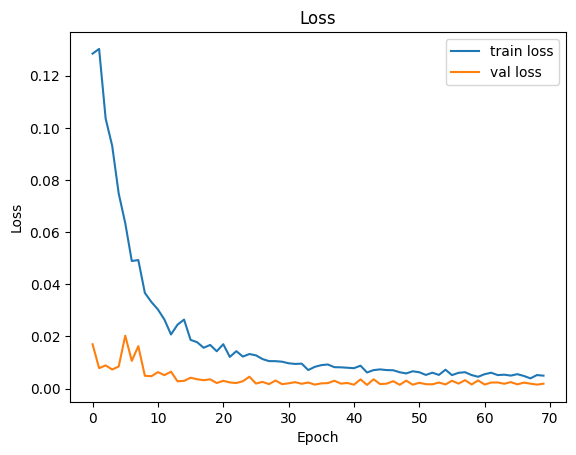

그래프 출력 완료


In [2]:
import FinanceDataReader as fdr
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, GRU, LSTM, Dropout

def MinMaxScaler(data):
    numerator = data - np.min(data, 0)
    denominator = np.max(data, 0) - np.min(data, 0)
    return numerator / (denominator + 1e-7)

df = fdr.DataReader('005930', '2018-05-04', '2020-01-22')
dfx = df[['Open','High','Low','Volume','Close']]
dfx = MinMaxScaler(dfx)
dfy = dfx[['Close']]
dfx = dfx[['Open','High','Low','Volume']]

x = dfx.values.tolist()
y = dfy.values.tolist()

window_size = 10
data_x = []
data_y = []
for i in range(len(y) - window_size):
    _x = x[i : i + window_size]
    _y = y[i + window_size]
    data_x.append(_x)
    data_y.append(_y)

train_size = int(len(data_y) * 0.7)
val_size = int(len(data_y) * 0.2)
train_x = np.array(data_x[0 : train_size])
train_y = np.array(data_y[0 : train_size])
val_x = np.array(data_x[train_size:train_size+val_size])
val_y = np.array(data_y[train_size:train_size+val_size])

test_size = len(data_y) - train_size - val_size
test_x = np.array(data_x[train_size+val_size: len(data_x)])
test_y = np.array(data_y[train_size+val_size: len(data_y)])

print('훈련 데이터의 크기 :', train_x.shape, train_y.shape)
print('검증 데이터의 크기 :', val_x.shape, val_y.shape)
print('테스트 데이터의 크기 :', test_x.shape, test_y.shape)

#rnn

model = Sequential()
model.add(SimpleRNN(units=20, activation='tanh', return_sequences=True, input_shape=(10,4)))
model.add(Dropout(0.1))
model.add(SimpleRNN(units=20, activation='tanh'))
model.add(Dropout(0.1))
model.add(Dense(units=1))
model.summary()

model.compile(optimizer='adam', loss='mean_squared_error')

print("모델 훈련 시작")
history = model.fit(train_x, train_y, validation_data = (val_x, val_y), epochs=70, batch_size=30)


plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
print("그래프 출력 완료")


/home/hsm/python_ai/python_code/intro/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 10, 20)         │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 20)             │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,101 (16.02 KB)

 Trainable params: 4,101 (16.02 KB)

 Non-trainable params: 0 (0.00 B)

모델 훈련 시작
Epoch 1/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0367 - val_loss: 0.0043
Epoch 2/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0104 - val_loss: 0.0092
Epoch 3/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055 - val_loss: 0.0146
Epoch 4/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0053 - val_loss: 0.0050
Epoch 5/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0053 - val_loss: 0.0075
Epoch 6/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0036 - val_loss: 0.0066
Epoch 7/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0038 - val_loss: 0.0054
Epoch 8/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0040 - val_loss: 0.0043
Epoch 9/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0036 - val_loss: 0.0052
Epoch 10/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0037 - val_loss: 0.0032
Epoch 11/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 12/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.002

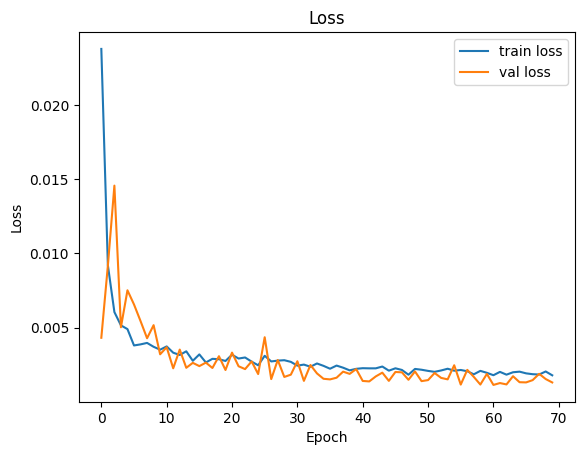

그래프 출력 완료


In [4]:
#gru

model = Sequential()
model.add(GRU(units=20, activation='tanh', return_sequences=True, input_shape=(10,4)))
model.add(Dropout(0.1))
model.add(GRU(units=20, activation='tanh'))
model.add(Dropout(0.1))
model.add(Dense(units=1))
model.summary()

model.compile(optimizer='adam', loss='mean_squared_error')

print("모델 훈련 시작")
history = model.fit(train_x, train_y, validation_data = (val_x, val_y), epochs=70, batch_size=30)


plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
print("그래프 출력 완료")

/home/hsm/python_ai/python_code/intro/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 20)         │         2,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20)             │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,301 (20.71 KB)

 Non-trainable params: 0 (0.00 B)

모델 훈련 시작
Epoch 1/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0624 - val_loss: 0.0194
Epoch 2/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0075 - val_loss: 0.0045
Epoch 3/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0084 - val_loss: 0.0151
Epoch 4/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060 - val_loss: 0.0136
Epoch 5/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0052 - val_loss: 0.0072
Epoch 6/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0048 - val_loss: 0.0081
Epoch 7/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0050 - val_loss: 0.0087
Epoch 8/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - val_loss: 0.0067
Epoch 9/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038 - val_loss: 0.0075
Epoch 10/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0036 - val_loss: 0.0057
Epoch 11/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0044 - val_loss: 0.0062
Epoch 12/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.004

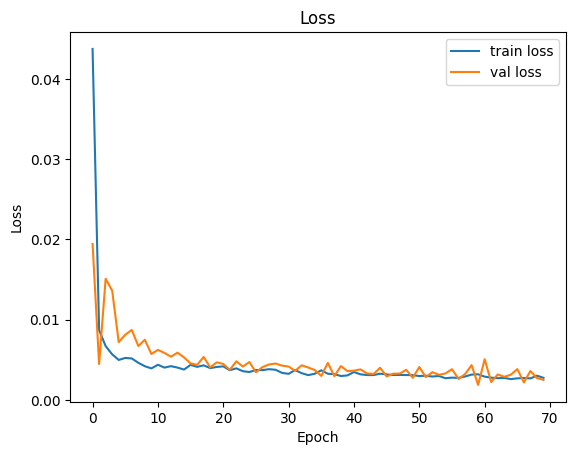

그래프 출력 완료


In [5]:
#lstm

model = Sequential()
model.add(LSTM(units=20, activation='tanh', return_sequences=True, input_shape=(10,4)))
model.add(Dropout(0.1))
model.add(LSTM(units=20, activation='tanh'))
model.add(Dropout(0.1))
model.add(Dense(units=1))
model.summary()

model.compile(optimizer='adam', loss='mean_squared_error')

print("모델 훈련 시작")
history = model.fit(train_x, train_y, validation_data = (val_x, val_y), epochs=70, batch_size=30)


plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
print("그래프 출력 완료")